# Time Series Analysis of Daily Minimum Temperatures

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

: 

In [3]:
df = pd.read_csv("../csv2/daily-min-temperatures.csv")
print(df.head(5))

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


In [4]:
len(df)

3650

## Dataset Description

The dataset used in this analysis is the **Daily Minimum Temperatures** dataset, obtained from the following public repository:

 https://github.com/jbrownlee/Datasets

The dataset contains daily observations with two variables:

- **Date**: the date of the observation  
- **Temp**: the recorded minimum temperature  

The data spans multiple years and is structured as a univariate time series.

---

## Why this dataset?

This dataset was selected for several reasons:

- It is publicly available and widely used in time series learning contexts.
- It contains a relatively large number of observations (3650), which makes it suitable for statistical modeling.
- The dataset is simple and clean, allowing the analysis to focus on time series methods rather than data preprocessing.
- It represents a real-world time series with natural variability.

---

## Objective of the analysis

The objective of this analysis is to explore the temporal structure of the data and understand its behavior over time.

In particular, the analysis will focus on:

- Visualizing the time series  
- Evaluating stationarity  
- Analyzing autocorrelation patterns (ACF and PACF)  
- Identifying suitable models for time series forecasting  

The goal is to apply classical time series techniques and evaluate their performance on this dataset.

In [5]:
# Shape of the dataset
print("\nShape of the dataset (rows, columns):")
print(df.shape)



Shape of the dataset (rows, columns):
(3650, 2)


In [6]:
# Column names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Date', 'Temp'], dtype='str')


In [7]:
# Data types and general information
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 57.2 KB
None


In [8]:
# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Date    0
Temp    0
dtype: int64


In [9]:
# Check for duplicated rows
print("\nNumber of duplicated rows:")
print(df.duplicated().sum())



Number of duplicated rows:
0


In [10]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

# Check again after conversion
print(df.head(5))
print(df.info())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8
<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB
None


## Exploratory Data Analysis

In this section, we made an exploratory analysis of the daily minimum temperature series.
The goal is to understand the distribution of the data, detect seasonal patterns, and identify
any notable trends across months and years.

In [11]:
# Auxiliary columns for analysis
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Month_name"] = df.index.strftime("%b")

### Descriptive Statistics

The table below summarizes the main statistical characteristics of the temperature variable.
We can observe the central tendency, spread, and shape of the distribution.

In [12]:
print("=== Descriptive Statistics ===")
print(df["Temp"].describe().round(2))
print(f"\nMedian : {df['Temp'].median():.2f}")
print(f"Asimetry (skewness): {df['Temp'].skew():.4f}")
print(f"Curtosis : {df['Temp'].kurtosis():.4f}")

=== Descriptive Statistics ===
count    3650.00
mean       11.18
std         4.07
min         0.00
25%         8.30
50%        11.00
75%        14.00
max        26.30
Name: Temp, dtype: float64

Median : 11.00
Asimetry (skewness): 0.1723
Curtosis : -0.0631


### Temperature Distribution

The histogram below shows the overall distribution of daily minimum temperatures.
The distribution appears  symmetric and bell-shaped, centered around 11–12°C,
which suggests the data is close to normally distributed with no strong skew.
The KDE curve confirms this shape, and the mean and median are very close to each other.

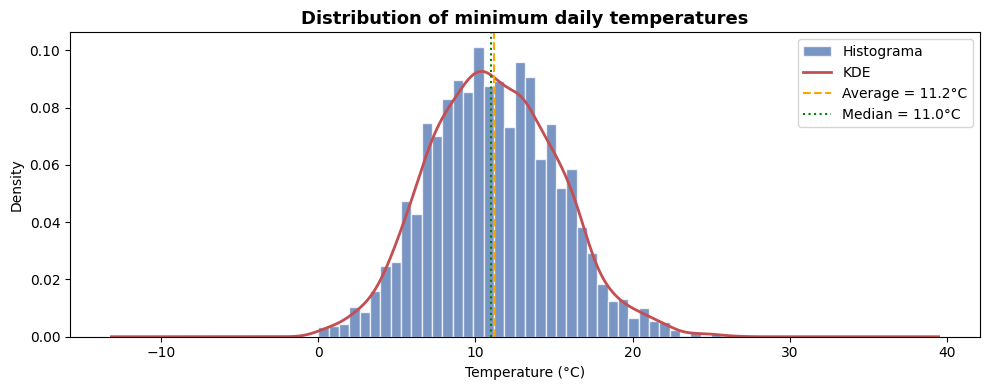

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["Temp"], bins=40, color="#4C72B0", edgecolor="white",
        alpha=0.75, density=True, label="Histograma")
df["Temp"].plot.kde(ax=ax, color="#C44E52", linewidth=2, label="KDE")
ax.axvline(df["Temp"].mean(),   color="orange", linestyle="--", linewidth=1.5,
           label=f"Average = {df['Temp'].mean():.1f}°C")
ax.axvline(df["Temp"].median(), color="green",  linestyle=":",  linewidth=1.5,
           label=f"Median = {df['Temp'].median():.1f}°C")
ax.set_title("Distribution of minimum daily temperatures", fontsize=13, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### Monthly Distribution

The boxplot below displays the temperature distribution for each month of the year.
A clear seasonal pattern is visible: temperatures are higher during the summer months
(December–February in Melbourne's Southern Hemisphere climate) and lower in winter
(June–August). June and July show the lowest medians and the least variability,
while January and December present the highest values.

/tmp/ipykernel_925/2161322838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Month_name", y="Temp", order=month_order,


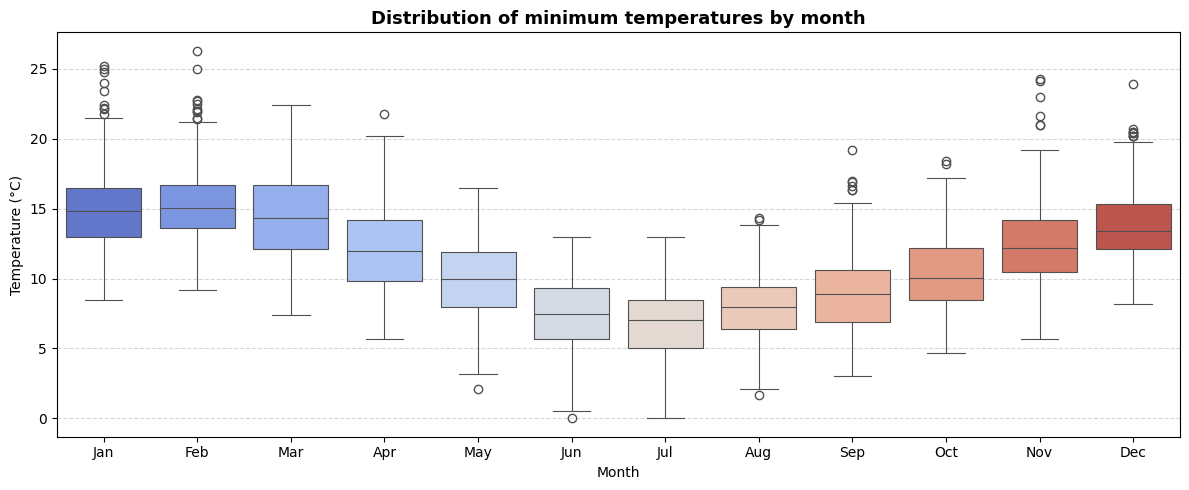

In [14]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="Month_name", y="Temp", order=month_order,
            palette="coolwarm", linewidth=0.8, ax=ax)
ax.set_title("Distribution of minimum temperatures by month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Yearly Distribution

The boxplot below shows the temperature distribution for each year in the dataset (1981–1990).
The overall spread and median remain relatively stable across years, suggesting no strong
long-term trend. However, some years such as 1983 and 1988 show  higher variability,
which could reflect anomalous weather events during those periods.

/tmp/ipykernel_925/3838406918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Year", y="Temp", palette="Blues_d",


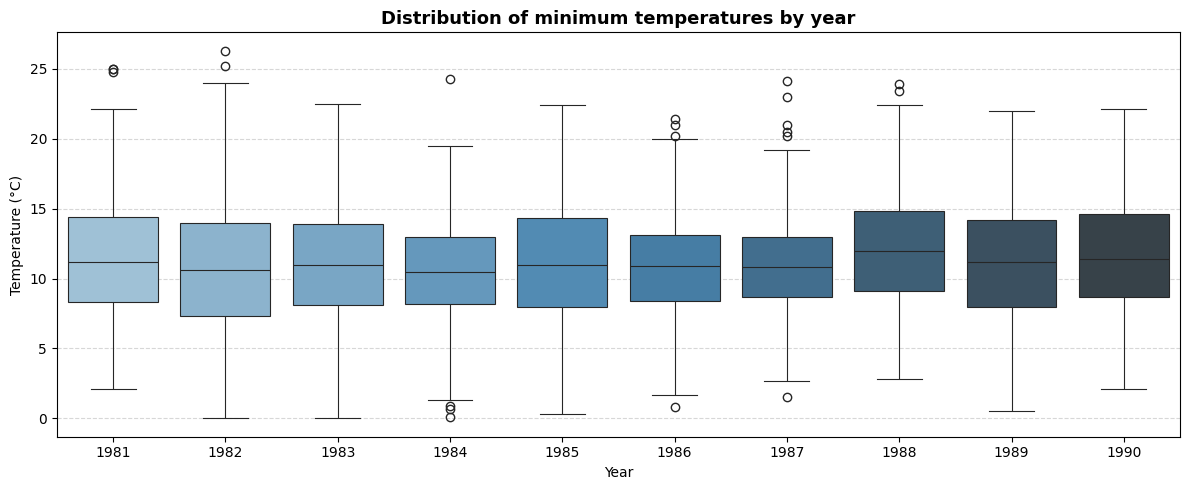

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="Year", y="Temp", palette="Blues_d",
            linewidth=0.8, ax=ax)
ax.set_title("Distribution of minimum temperatures by year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly Average Temperature Heatmap

The heatmap provides a compact view of the average minimum temperature for each
month across all years. The seasonal pattern is clearly visible in every row,
with warmer tones in summer months and cooler tones in winter. The consistency
of this pattern across all years reinforces the strong seasonality of the series,
which will be an important factor in the modelling phase.

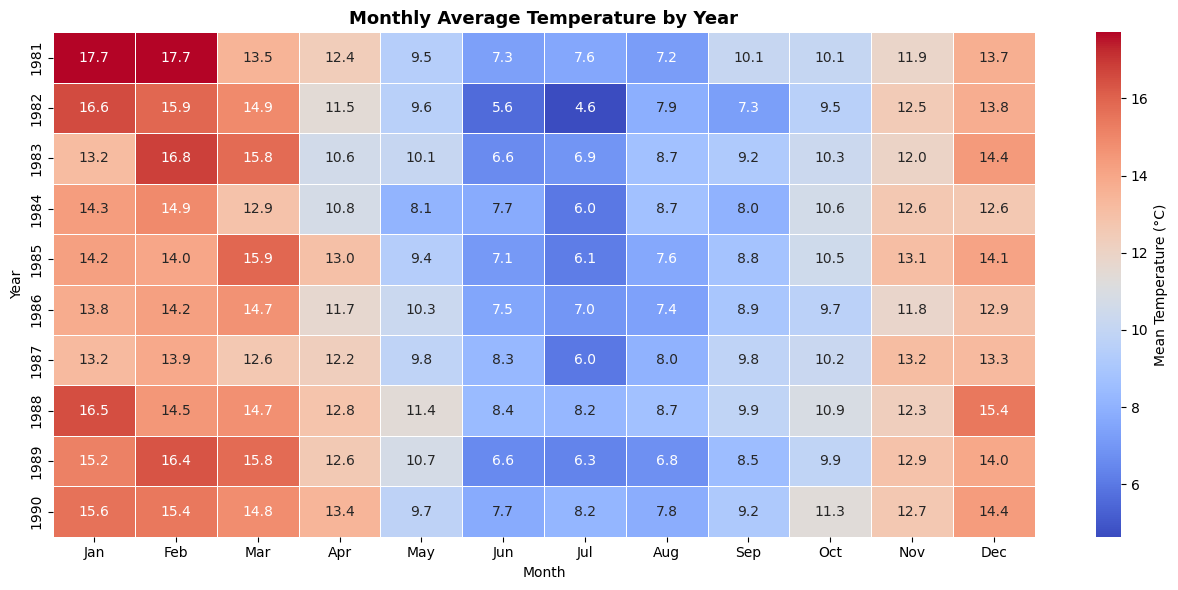

In [16]:
pivot = df.groupby(["Year", "Month"])["Temp"].mean().unstack()
pivot.columns = month_order

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm",
            linewidths=0.4, linecolor="white", ax=ax,
            cbar_kws={"label": "Mean Temperature (°C)"})
ax.set_title("Monthly Average Temperature by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

## Time Series Visualization
The graph shows how the temperature changes over time.

We can see a clear repeating pattern every year, which means the data has seasonality. Temperatures go up in some months and down in others.

There is no clear long-term trend, because the values do not keep increasing or decreasing over the years.

There are also small random changes from day to day, which is normal in real data.

Overall, the series shows seasonality with some noise and no strong trend.

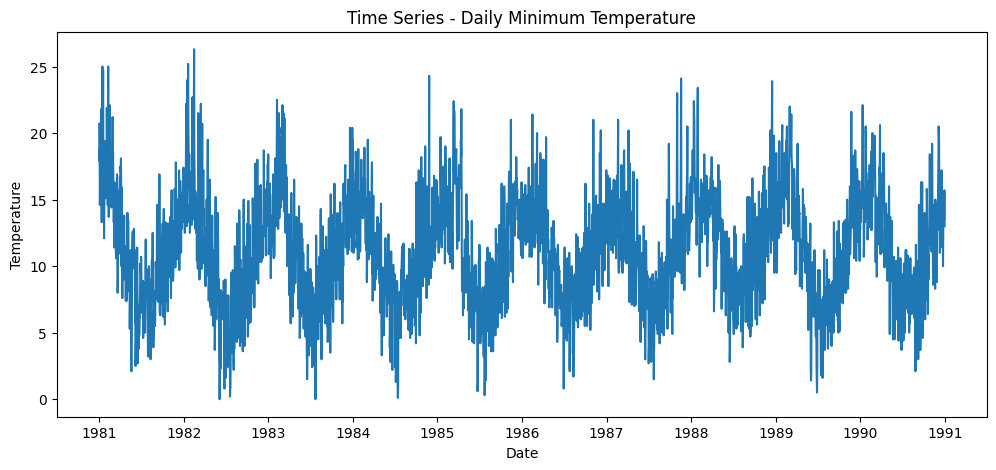

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Temp"])
plt.title("Time Series - Daily Minimum Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

## Trend Visualization

The graph shows the original temperature values and the rolling mean.

The red line (rolling mean) makes the pattern clearer and shows a repeating cycle over time.

We can see that the data follows a seasonal pattern, with regular peaks and drops each year.

There is no strong long-term trend, since the average level stays similar over time.

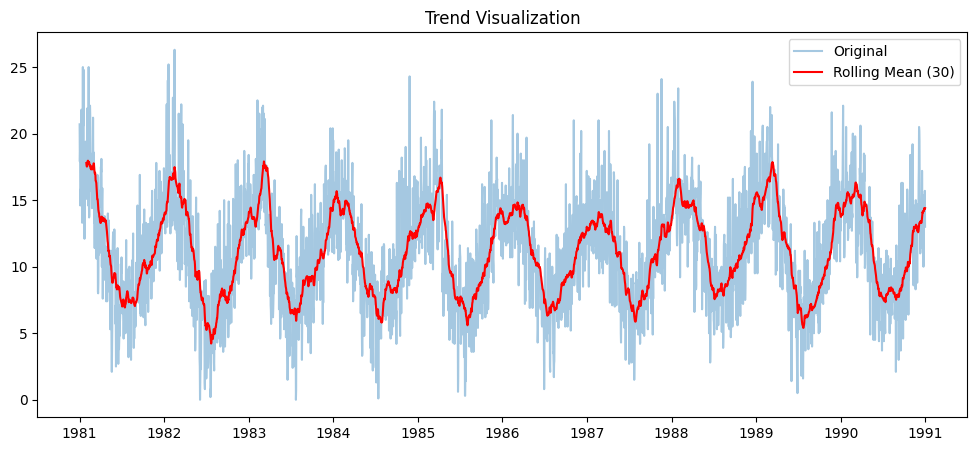

In [18]:
df["rolling_mean"] = df["Temp"].rolling(window=30).mean()
#The red line is a smoothed version of the data. It helps to see the general pattern more clearly.
plt.figure(figsize=(12,5))
plt.plot(df["Temp"], alpha=0.4, label="Original")
plt.plot(df["rolling_mean"], color="red", label="Rolling Mean (30)")
plt.legend()
plt.title("Trend Visualization")
plt.show()

## Time Series Decomposition

The decomposition separates the time series into three components: trend, seasonality, and residuals.

The trend shows a slight variation over time, but no strong long-term increase or decrease.

The seasonal component shows a clear and regular pattern that repeats every year, confirming strong seasonality in the data.

The residuals represent random noise, with no clear pattern.

Overall, the series is mainly driven by seasonality with some random fluctuations.

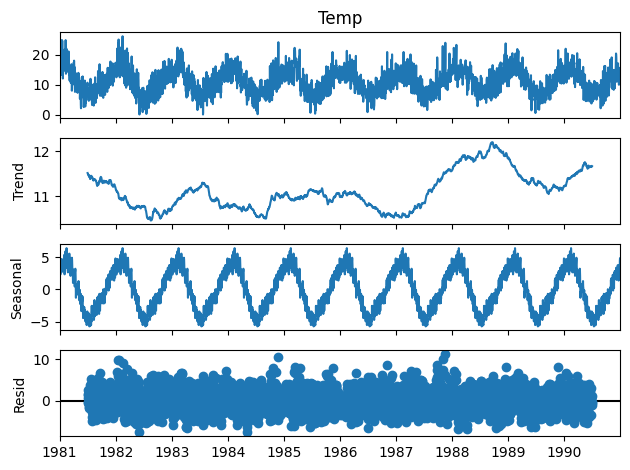

In [19]:
result = seasonal_decompose(df["Temp"], model="additive", period=365)
result.plot()
plt.show()

## Stationarity Test

To evaluate the stationarity of the time series, the Augmented Dickey-Fuller (ADF) test was applied.

The result shows a p-value lower than 0.05, which indicates that the series is stationary.

This means that the statistical properties of the data, such as the mean and variance, remain relatively constant over time.

Therefore, no differencing is required before applying time series models.

In [20]:
result = adfuller(df["Temp"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.444804924611697
p-value: 0.00024708263003610177


## ACF (Autocorrelation Function)
What does it measure?

- It measures how similar the time series is to itself over time
- It compares the current value with past values (lags)

What can be observed?
High values at the beginning
Gradual decay over time
No sharp cutoff

Interpretation

- There is temporal dependence in the data
- Current values are related to past observations

- Since there is no clear cutoff, the process is not a pure MA model

## PACF (Partial Autocorrelation Function)
What does it measure?

- It measures the direct relationship with each lag
- It removes the effect of intermediate lags

What can be observed?

There is a strong spike at lag 1 in the PACF, followed by gradually decreasing values.

This suggests that the series can be reasonably modeled using an AR(1) component, although the absence of a sharp cutoff indicates that the process may not be a perfectly pure AR model.

Therefore, ARIMA models with a dominant AR term (p=1) are a good starting point.




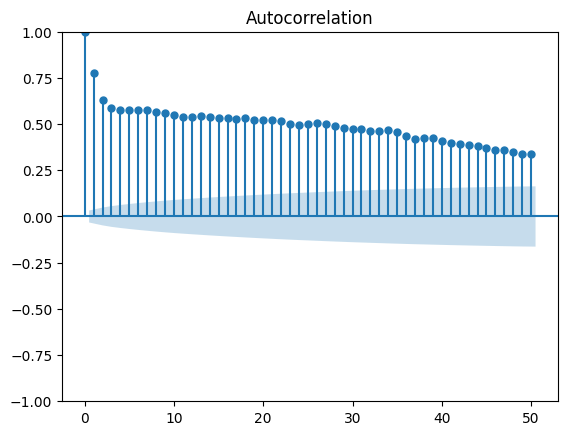

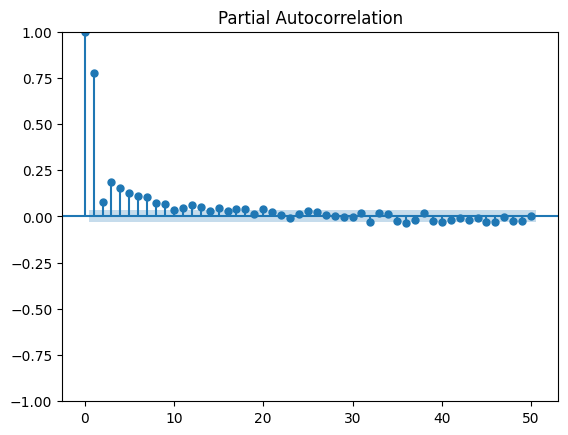

In [21]:
plot_acf(df["Temp"], lags=50)
plot_pacf(df["Temp"], lags=50)

plt.show()

After analyzing the ACF and PACF plots, an initial model structure can be proposed.

The PACF shows a strong spike at lag 1 followed by a gradual decay, which suggests the presence of a dominant autoregressive component of order 1 (AR(1)). This indicates that the current value of the series is strongly related to its immediate past value.

On the other hand, the ACF does not exhibit a clear cutoff, but rather a slow decay. This behavior suggests that a moving average (MA) component may also be present in the data. Therefore, different values of the MA order (q) will be explored to determine whether including this component improves model performance.

Since the Augmented Dickey-Fuller test confirmed that the series is stationary (p-value < 0.05), no differencing is required, and the parameter d is set to 0.

Based on these observations, several ARIMA models will be tested, keeping the autoregressive order fixed at p = 1 and varying the moving average order (q = 0, 1, 2).

In addition, previous analysis revealed a clear yearly seasonal pattern in the data. Therefore, seasonal models will also be considered using SARIMA, incorporating a seasonal period of 365 days.

The models to be evaluated include both non-seasonal (ARIMA) and seasonal (SARIMA) configurations. Their performance will be compared using appropriate error metrics such as RMSE, allowing the selection of the model that best captures the underlying structure of the data.

In [25]:
# First model: ARIMA(1,0,0) / AR(1)

# Train-test split
train = df["Temp"][:-365]
test = df["Temp"][-365:] # Last year as test set

print("Train size:", len(train))
print("Test size:", len(test))

# Fit ARIMA(1,0,0)
model_arima_100 = ARIMA(train, order=(1, 0, 0))
model_arima_100_fit = model_arima_100.fit()

print(model_arima_100_fit.summary())

# Forecast
forecast_arima_100 = model_arima_100_fit.forecast(steps=len(test))

# Evaluation metrics
mae_arima_100 = mean_absolute_error(test, forecast_arima_100)
rmse_arima_100 = np.sqrt(mean_squared_error(test, forecast_arima_100))

print("ARIMA(1,0,0) Results")
print(f"MAE: {mae_arima_100:.4f}")
print(f"RMSE: {rmse_arima_100:.4f}")


Train size: 3285
Test size: 365


/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3285
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -7785.783
Date:                Thu, 30 Apr 2026   AIC                          15577.566
Time:                        11:16:54   BIC                          15595.858
Sample:                             0   HQIC                         15584.115
                               - 3285                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1348      0.202     55.016      0.000      10.738      11.531
ar.L1          0.7748      0.010     74.552      0.000       0.754       0.795
sigma2         6.6995      0.154     43.594      0.0

/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


The dataset was divided into a training set of 3285 observations and a test set of 365 observations, corresponding to the last year of data.

The ARIMA(1,0,0) model was fitted to the training data. The estimated autoregressive coefficient (AR(1) ≈ 0.77) is highly significant (p-value < 0.001), indicating a strong dependence on the previous time step. The constant term is also significant, representing the average level of the series.

In terms of model diagnostics, the Ljung-Box test yields a p-value of 0.00, suggesting that the residuals are not white noise and that some structure remains unmodeled. Additionally, the Jarque-Bera test indicates that the residuals are not normally distributed.

Regarding predictive performance, the model achieves a Mean Absolute Error (MAE) of 3.21 and a Root Mean Squared Error (RMSE) of 3.88. Given the range of the temperature values, this indicates a moderate level of prediction accuracy.

Overall, the ARIMA(1,0,0) model captures short-term dependencies in the data and serves as a reasonable baseline. However, it does not fully explain the structure of the series, likely due to the presence of a strong seasonal component that is not accounted for in this model.